In [1]:
pip install geopandas pandas matplotlib

     GID_1 GID_0 COUNTRY               NAME_1  \
0  IND.1_1   IND   India  Andaman and Nicobar   
1  IND.2_1   IND   India       Andhra Pradesh   
2  IND.3_1   IND   India    Arunachal Pradesh   
3  Z07.3_1   Z07   India    Arunachal Pradesh   
4  IND.4_1   IND   India                Assam   

                          VARNAME_1 NL_NAME_1          TYPE_1  \
0  Andaman & Nicobar Islands|Andama        NA  Union Territor   
1                                NA        NA           State   
2  Agence de la Frontière du Nord-E        NA           State   
3  Agence de la Frontière du Nord-E        NA           State   
4                                NA        NA           State   

         ENGTYPE_1 CC_1 HASC_1  ISO_1  \
0  Union Territory   NA  IN.AN     NA   
1            State   NA  IN.AP  IN-AP   
2            State   NA  IN.AR  IN-AR   
3            State   NA  IN.AR     NA   
4            State   NA  IN.AS  IN-AS   

                                            geometry  
0  MULTIPOLY

<Axes: >

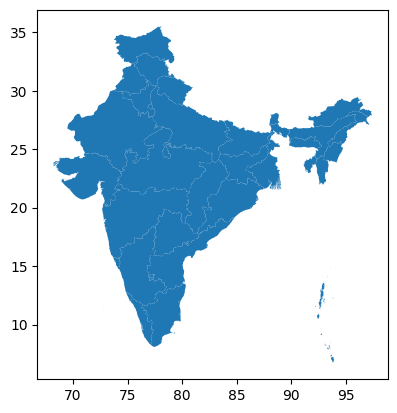

In [4]:
import geopandas as gpd

india_map = gpd.read_file("gadm41_IND_1.shp")

print(india_map.head())
india_map.plot()

In [5]:
import requests
import pandas as pd

In [6]:
url = "https://api.covid19india.org/data.json"

In [7]:
response = requests.get(url)
data = response.json()

In [8]:
print(data.keys())

dict_keys(['cases_time_series', 'statewise', 'tested'])


In [9]:
state_data = pd.DataFrame(data["statewise"])
state_data.head()

,active,confirmed,deaths,deltaconfirmed,deltadeaths,deltarecovered,lastupdatedtime,migratedother,recovered,state,statecode,statenotes
0,382019,32076974,429702,41574,491,39125,12/08/2021 00:42:15,12644,31252609,Total,TT,
1,6,7548,129,0,0,1,12/08/2021 00:42:17,0,7413,Andaman and Nicobar Islands,AN,
2,18417,1987051,13582,1869,18,2316,11/08/2021 19:12:15,0,1955052,Andhra Pradesh,AP,
3,2488,50793,251,188,3,233,12/08/2021 00:42:19,0,48054,Arunachal Pradesh,AR,[July 25]: All numbers corresponding to Papum ...
4,9472,577035,5434,886,14,1098,12/08/2021 00:41:20,1347,560782,Assam,AS,[Jan 1]: 1347 cases i.e Covid +'tive patients ...


In [10]:
state_data["confirmed"] = pd.to_numeric(state_data["confirmed"])
state_data["recovered"] = pd.to_numeric(state_data["recovered"])
state_data["deaths"] = pd.to_numeric(state_data["deaths"])

In [11]:
merged = india_map.merge(
    state_data,
    left_on="NAME_1",
    right_on="state"
)

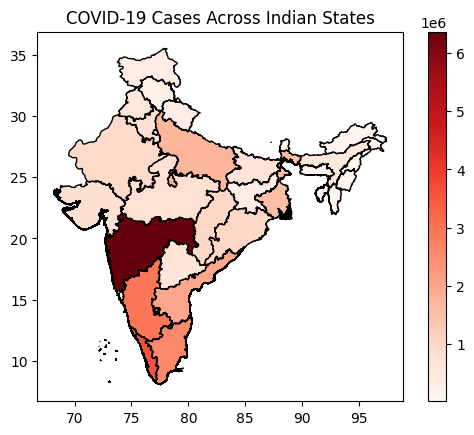

In [12]:
import matplotlib.pyplot as plt

merged.plot(
    column="confirmed",
    cmap="Reds",
    legend=True,
    edgecolor="black"
)

plt.title("COVID-19 Cases Across Indian States")
plt.show()

In [16]:
print(merged.columns)

Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry', 'active',
       'confirmed', 'deaths', 'deltaconfirmed', 'deltadeaths',
       'deltarecovered', 'lastupdatedtime', 'migratedother', 'recovered',
       'state', 'statecode', 'statenotes'],
      dtype='object')


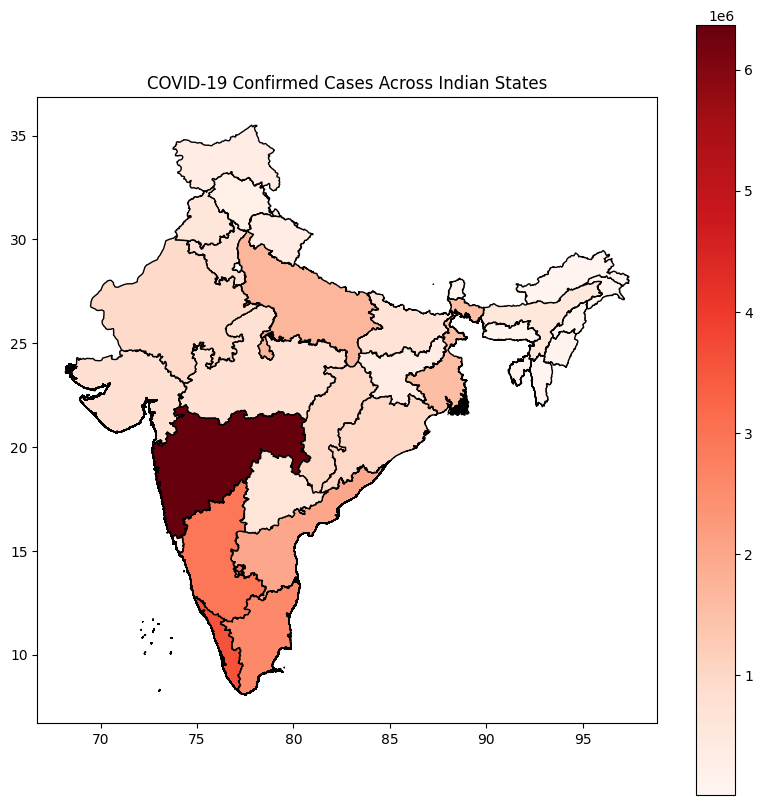

In [17]:
import matplotlib.pyplot as plt

merged.plot(
    column="confirmed",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    figsize=(10,10)
)

plt.title("COVID-19 Confirmed Cases Across Indian States")
plt.show()


<Axes: >

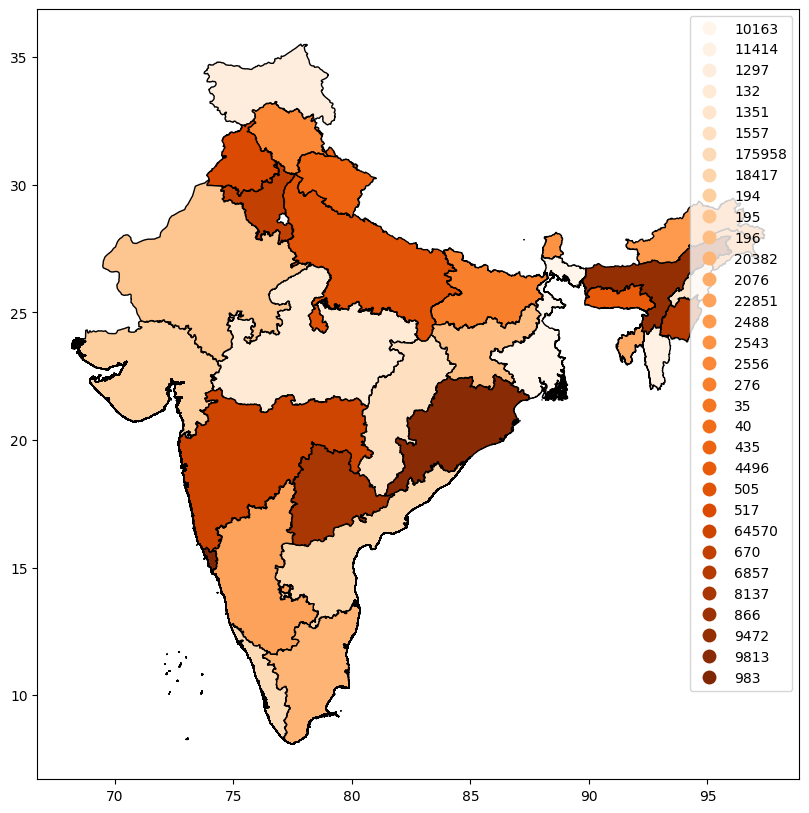

In [18]:
merged.plot(
    column="active",
    cmap="Oranges",
    legend=True,
    edgecolor="black",
    figsize=(10,10)
)

In [19]:
merged["fatality_rate"] = merged["deaths"] / merged["confirmed"]

<Axes: >

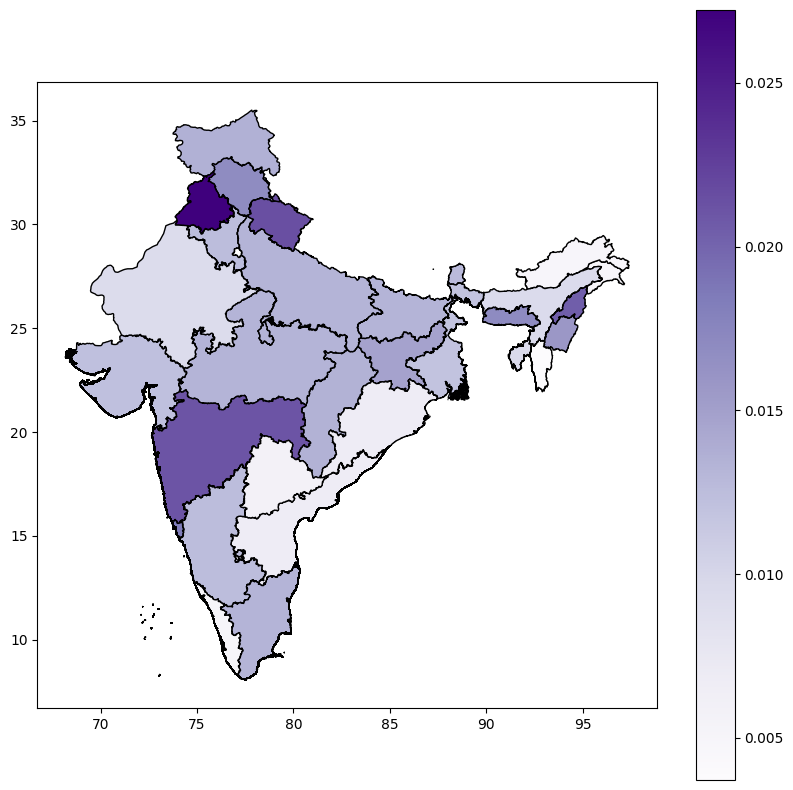

In [20]:
merged.plot(
    column="fatality_rate",
    cmap="Purples",
    legend=True,
    edgecolor="black",
    figsize=(10,10)
)

<Axes: >

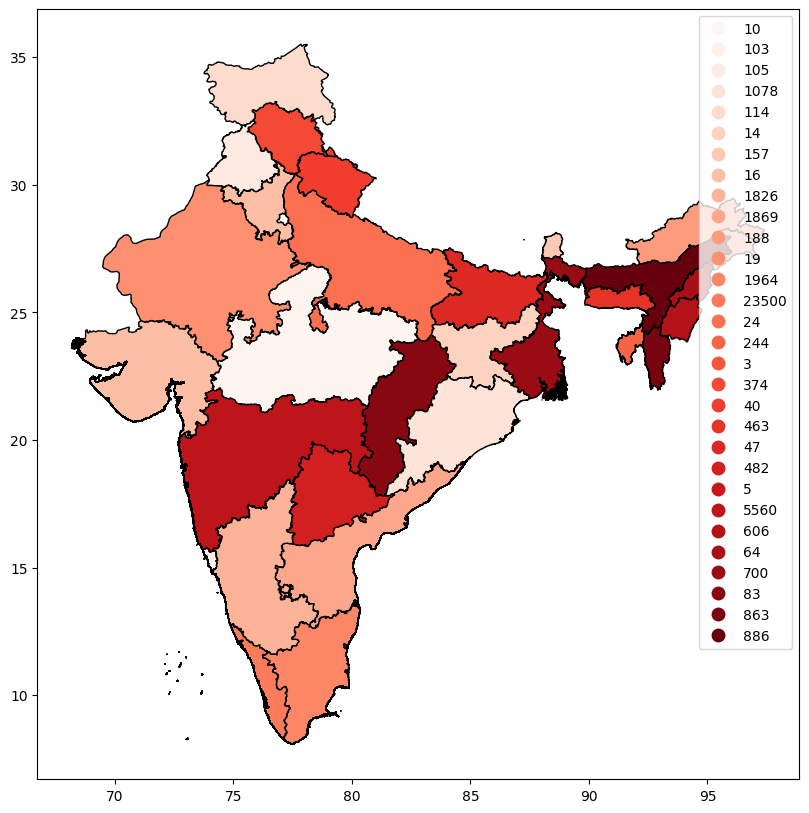

In [21]:
merged.plot(
    column="deltaconfirmed",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    figsize=(10,10)
)

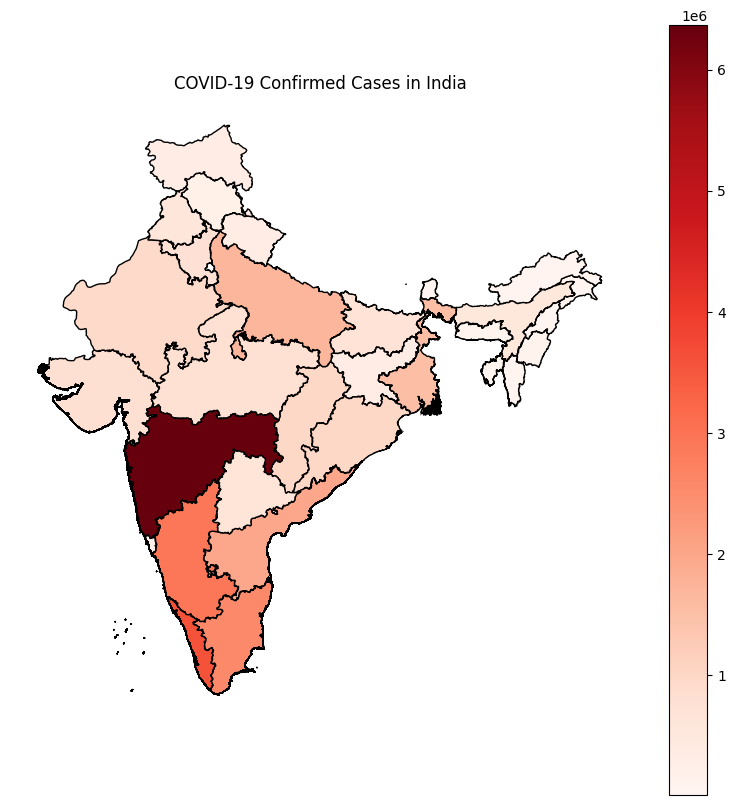

In [22]:
fig, ax = plt.subplots(figsize=(10,10))

merged.plot(
    column="confirmed",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("COVID-19 Confirmed Cases in India")
ax.axis("off")

plt.show()

<Axes: >

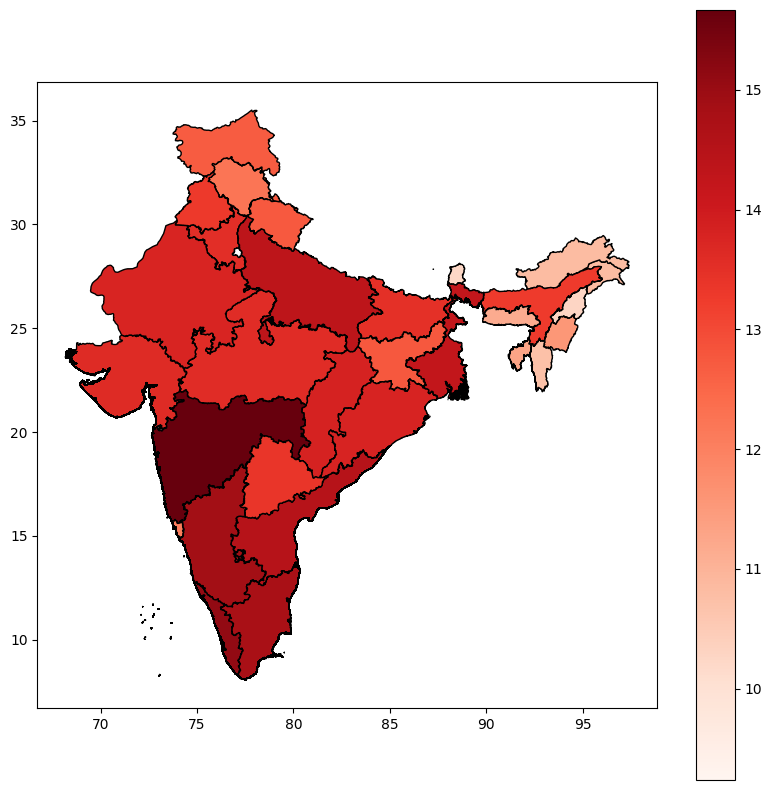

In [24]:
import numpy as np

merged["log_cases"] = np.log1p(merged["confirmed"])

merged.plot(
    column="log_cases",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    figsize=(10,10)
)

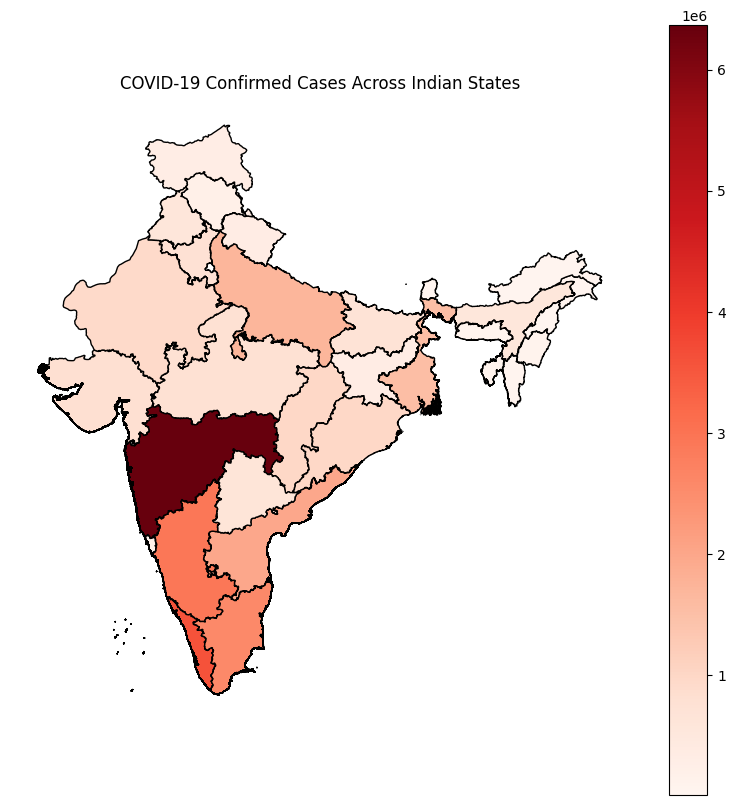

In [25]:
fig, ax = plt.subplots(figsize=(10,10))

merged.plot(
    column="confirmed",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("COVID-19 Confirmed Cases Across Indian States")
ax.axis("off")

plt.show()

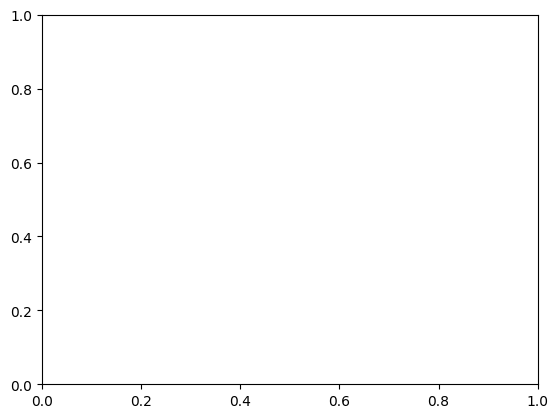

In [26]:
for idx, row in merged.iterrows():
    plt.annotate(
        text=row["statecode"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=7
    )